In [12]:
import os
import re
import sys
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import umap
from sentence_transformers import SentenceTransformer
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances_argmin

OUTPUT_DIR = "hasil_clustering"

if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR)

print("Setup selesai. Output folder:", os.path.abspath(OUTPUT_DIR))

Setup selesai. Output folder: c:\Users\andika\Projects\clustering-judul-skripsi\hasil_clustering


In [13]:
print("Python:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: c:\Program Files\Python314\python.exe
Torch: 2.10.0+cu126
CUDA available: True


In [14]:
df = pd.read_csv("dataset_titles.csv")
print(f"Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print("Kolom:", df.columns.tolist())
df.head(3)

Dataset: 792 baris, 8 kolom
Kolom: ['id', 'title', 'category', 'year', 'author', 'advisor', 'url', 'abstract']


,id,title,category,year,author,advisor,url,abstract
0,1,Alarm Limitasi Pengunjung untuk Ruang Umum Ter...,Teknik Informatika,2021,Angelica Kirana Sandra Dewi,"Martin C.T. Manullang, S.T., M.T.",https://repo.itera.ac.id/depan/submission/SB21...,Dengan mulai kembali pulihnya perekenomian di ...
1,2,ALAT DETEKSI DAN PENGUSIRAN HAMA TIKUS DAN BUR...,Teknik Informatika,2021,Indri Wulan Dari,"Meida Cahyo Untoro, S.Kom.,M.Kom.",https://repo.itera.ac.id/depan/submission/SB22...,Alat Deteksi dan Pengusiran Hama Tikus dan Bur...
2,3,Alat Monitoring Tanah dan Pengusir Hama Otomat...,Teknik Informatika,2021,Leo Viranda Millennium,"Meida Cahyo Untoro, S.Kom., M.Kom.",https://repo.itera.ac.id/depan/submission/SB21...,Padi dalam pertumbuhannya memerlukan kondisi l...


In [ ]:
TITLE_REPEAT = 3  # title diulang agar bobotnya lebih besar vs abstract yang lebih panjang

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def prepare_text(row):
    title = str(row['title']) if pd.notna(row['title']) else ''
    abstract = str(row['abstract']) if pd.notna(row['abstract']) else ''
    parts = [title.strip()] * TITLE_REPEAT
    if abstract.strip():
        parts.append(abstract.strip())
    return re.sub(r'\s+', ' ', ' '.join(parts)).strip()

df['clean_title'] = df['title'].apply(lambda x: clean_text(str(x)) if pd.notna(x) else '')
df['text'] = df.apply(prepare_text, axis=1)
texts = df['text'].tolist()

print(f"Jumlah teks: {len(texts)}")
print(f"TITLE_REPEAT: {TITLE_REPEAT}")
print(f"Rata-rata panjang teks: {sum(len(t) for t in texts) / len(texts):.0f} karakter")
print("Contoh teks pertama:")
print(texts[0][:400])


Jumlah teks: 792
TITLE_REPEAT: 3
Rata-rata panjang teks: 1837 karakter
Contoh teks pertama:
Alarm Limitasi Pengunjung untuk Ruang Umum Tertutup Berbasis Crowd Counting Alarm Limitasi Pengunjung untuk Ruang Umum Tertutup Berbasis Crowd Counting Alarm Limitasi Pengunjung untuk Ruang Umum Tertutup Berbasis Crowd Counting Dengan mulai kembali pulihnya perekenomian di masa pandemik Covid-19 ini, aktifitas ekonomi kini kembali berjalan lagi. Sektor bisnis dan perdagangan pun mulai dibuka kemba


In [16]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
device = "cuda"
print(f"Device: {device}")

st_model = SentenceTransformer(MODEL_NAME, device=device)
print(f"Model '{MODEL_NAME}' berhasil dimuat.")

Device: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17620.52it/s]
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2' berhasil dimuat.


In [17]:
print("Membuat embeddings...")
embeddings = st_model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
print(f"\nShape embeddings: {embeddings.shape}")

np.save(os.path.join(OUTPUT_DIR, "embeddings.npy"), embeddings)
print(f"Embeddings disimpan ke {OUTPUT_DIR}/embeddings.npy")

Membuat embeddings...


Batches: 100%|██████████| 25/25 [00:17<00:00,  1.43it/s]


Shape embeddings: (792, 768)
Embeddings disimpan ke hasil_clustering/embeddings.npy


In [18]:
# Reduksi dimensi dengan UMAP sebelum clustering (non-linear, preserves local topology)
N_COMPONENTS_UMAP = 20

print(f"Membuat UMAP embeddings {embeddings.shape[1]}D → {N_COMPONENTS_UMAP}D untuk clustering...")
reducer_cluster = umap.UMAP(
    n_components=N_COMPONENTS_UMAP,
    n_neighbors=30,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
    verbose=True,
)
embeddings_umap = reducer_cluster.fit_transform(embeddings)
print(f"\nShape embeddings_umap: {embeddings_umap.shape}")

C:\Users\andika\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Membuat UMAP embeddings 768D → 20D untuk clustering...
UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=20, n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Wed Mar 11 21:26:13 2026 Construct fuzzy simplicial set
Wed Mar 11 21:26:14 2026 Finding Nearest Neighbors
Wed Mar 11 21:26:14 2026 Finished Nearest Neighbor Search
Wed Mar 11 21:26:14 2026 Construct embedding


Epochs completed:  10%| █          51/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs


Epochs completed:  30%| ███        152/500 [00:00]

...

	completed  300  /  500 epochs
	completed  350  /  500 epochs


Epochs completed:  79%| ███████▉   395/500 [00:00]

	completed  400  /  500 epochs


Epochs completed: 100%| ██████████ 500/500 [00:01]

	completed  450  /  500 epochs
Wed Mar 11 21:26:15 2026 Finished embedding

Shape embeddings_umap: (792, 20)


Grid search HDBSCAN pada UMAP 20D embeddings...
 mcs | min_s |   csm |  n_cl |  noise% |  silhouette
-------------------------------------------------------
  10 |    10 |   eom |    18 |   26.6% |      0.5517
  10 |    10 |  leaf |    19 |   34.7% |      0.5858
  10 |     5 |   eom |    22 |   24.4% |      0.5320
  10 |     5 |  leaf |    24 |   30.6% |      0.5507
  10 |     2 |   eom |    24 |   23.1% |      0.5206
  10 |     2 |  leaf |    27 |   27.3% |      0.5051
  12 |    12 |   eom |    14 |   32.1% |      0.5553
  12 |    12 |  leaf |    16 |   44.7% |      0.6233
  12 |     6 |   eom |    16 |   26.1% |      0.5309
  12 |     6 |  leaf |    18 |   28.0% |      0.5406
  12 |     3 |   eom |    20 |   26.3% |      0.5295
  12 |     3 |  leaf |    20 |   26.3% |      0.5295
  15 |    15 |   eom |    11 |   35.7% |      0.5706
  15 |    15 |  leaf |    13 |   48.7% |      0.6201
  15 |     7 |   eom |    14 |   25.9% |      0.5373
  15 |     7 |  leaf |    16 |   30.4% |      0.

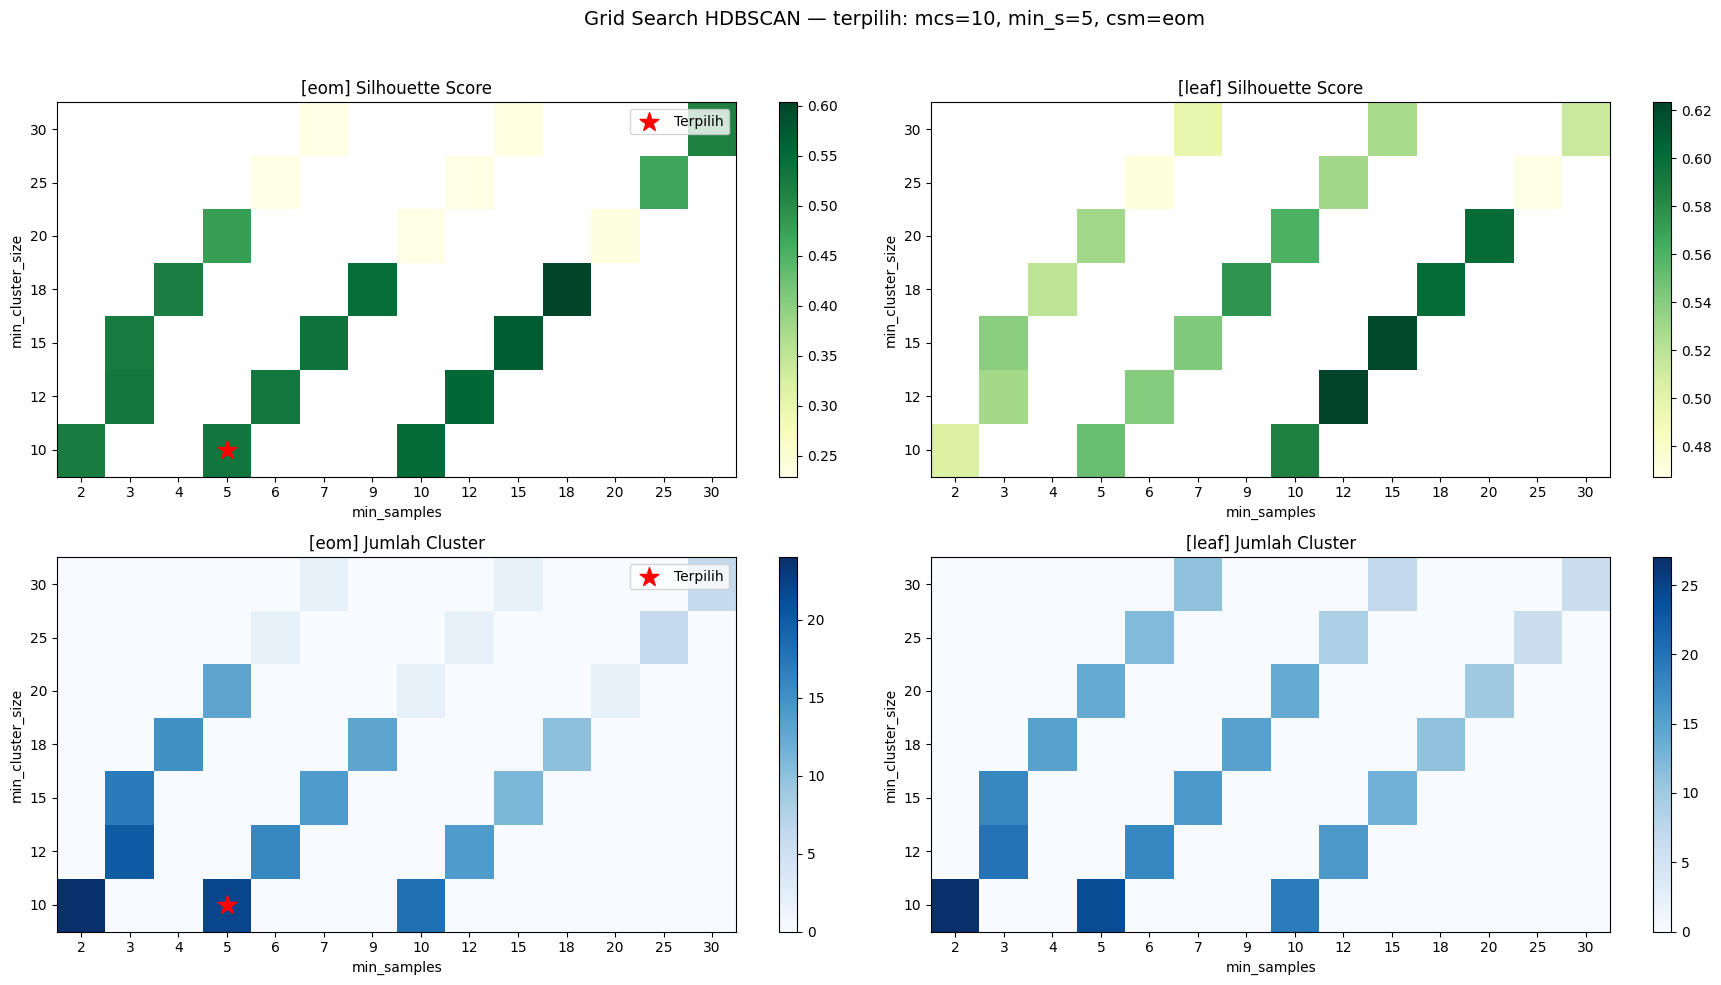

Plot disimpan ke hasil_clustering/hdbscan_param_search.png


In [19]:

# Grid search: min_cluster_size × min_samples × cluster_selection_method
# Range mcs dinaikkan agar cluster lebih sedikit (target 15–30 cluster)
MIN_SIZES         = [10, 12, 15, 18, 20, 25, 30]
MIN_SAMPLES_FRACS = [1.0, 0.5, 0.25]
CSM_VALUES        = ['eom', 'leaf']

print(f"Grid search HDBSCAN pada UMAP {N_COMPONENTS_UMAP}D embeddings...")
print(f"{'mcs':>4} | {'min_s':>5} | {'csm':>5} | {'n_cl':>5} | {'noise%':>7} | {'silhouette':>11}")
print("-" * 55)

hdb_results = []
for mcs in MIN_SIZES:
    for frac in MIN_SAMPLES_FRACS:
        min_s = max(1, int(mcs * frac))
        for csm in CSM_VALUES:
            hdb = HDBSCAN(
                min_cluster_size=int(mcs),
                min_samples=int(min_s),
                cluster_selection_method=csm,
                metric='euclidean',
                copy=True,
            )
            lbls = hdb.fit_predict(embeddings_umap)
            n_cl = len(set(lbls)) - (1 if -1 in lbls else 0)
            n_noise = int((lbls == -1).sum())
            noise_pct = n_noise / len(lbls) * 100
            mask = lbls != -1
            if n_cl >= 2 and mask.sum() > n_cl:
                sil = silhouette_score(embeddings_umap[mask], lbls[mask])
            else:
                sil = float('nan')
            hdb_results.append((mcs, min_s, csm, n_cl, n_noise, noise_pct, sil))
            print(f"{mcs:>4} | {min_s:>5} | {csm:>5} | {n_cl:>5} | {noise_pct:>6.1f}% | {sil:>11.4f}")


valid = [r for r in hdb_results
         if r[5] < 18 and 15 <= r[3] <= 30 and not np.isnan(r[6])]
if not valid:
    valid = [r for r in hdb_results
             if r[5] < 25 and 10 <= r[3] <= 35 and not np.isnan(r[6])]
if not valid:
    valid = [r for r in hdb_results if not np.isnan(r[6])]

if valid:
    best = max(valid, key=lambda r: r[6])
    BEST_MCS, BEST_MIN_S, BEST_CSM = int(best[0]), int(best[1]), best[2]
else:
    BEST_MCS, BEST_MIN_S, BEST_CSM = 15, 8, 'leaf'

print(f"\nParameter terpilih: min_cluster_size={BEST_MCS}, min_samples={BEST_MIN_S}, cluster_selection_method='{BEST_CSM}'")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
uniq_mcs   = MIN_SIZES
uniq_min_s = sorted(set(r[1] for r in hdb_results))

for col_i, csm in enumerate(CSM_VALUES):
    sil_arr = np.full((len(uniq_mcs), len(uniq_min_s)), np.nan)
    ncl_arr = np.zeros_like(sil_arr)
    for r in hdb_results:
        if r[2] != csm: continue
        i = uniq_mcs.index(r[0])
        j = uniq_min_s.index(r[1])
        sil_arr[i, j] = 0 if np.isnan(r[6]) else r[6]
        ncl_arr[i, j] = r[3]

    for row_i, (arr, title, cmap) in enumerate([
        (sil_arr, f'[{csm}] Silhouette Score', 'YlGn'),
        (ncl_arr, f'[{csm}] Jumlah Cluster',   'Blues'),
    ]):
        ax = axes[row_i][col_i]
        im = ax.imshow(arr, aspect='auto', cmap=cmap, origin='lower')
        ax.set_xticks(range(len(uniq_min_s))); ax.set_xticklabels(uniq_min_s)
        ax.set_yticks(range(len(uniq_mcs)));   ax.set_yticklabels(uniq_mcs)
        ax.set_xlabel('min_samples'); ax.set_ylabel('min_cluster_size')
        ax.set_title(title, fontsize=12)
        if BEST_CSM == csm:
            bi = uniq_mcs.index(BEST_MCS)
            bj = uniq_min_s.index(BEST_MIN_S)
            ax.scatter([bj], [bi], s=200, c='red', marker='*', zorder=5, label='Terpilih')
            ax.legend()
        plt.colorbar(im, ax=ax)

plt.suptitle(f'Grid Search HDBSCAN — terpilih: mcs={BEST_MCS}, min_s={BEST_MIN_S}, csm={BEST_CSM}', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(OUTPUT_DIR, "hdbscan_param_search.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot disimpan ke {OUTPUT_DIR}/hdbscan_param_search.png")


In [20]:
print(f"Menjalankan HDBSCAN: min_cluster_size={BEST_MCS}, min_samples={BEST_MIN_S}, cluster_selection_method='{BEST_CSM}'...")
hdbscan_model = HDBSCAN(
    min_cluster_size=int(BEST_MCS),
    min_samples=int(BEST_MIN_S),
    cluster_selection_method=BEST_CSM,
    metric='euclidean',
    copy=True,
)
cluster_labels_raw = hdbscan_model.fit_predict(embeddings_umap)

n_clusters = len(set(cluster_labels_raw)) - (1 if -1 in cluster_labels_raw else 0)
n_noise_raw = int((cluster_labels_raw == -1).sum())
print(f"\nJumlah cluster (raw): {n_clusters}")
print(f"Noise (raw)         : {n_noise_raw} ({n_noise_raw/len(cluster_labels_raw)*100:.1f}%)")

cluster_ids = sorted(set(cluster_labels_raw[cluster_labels_raw != -1]))
centroids = np.array([
    embeddings_umap[cluster_labels_raw == cid].mean(axis=0)
    for cid in cluster_ids
])

cluster_labels = cluster_labels_raw.copy()
noise_idx = np.where(cluster_labels_raw == -1)[0]
if len(noise_idx) > 0:
    nearest = pairwise_distances_argmin(embeddings_umap[noise_idx], centroids)
    for idx, near in zip(noise_idx, nearest):
        cluster_labels[idx] = cluster_ids[near]

n_noise_after = int((cluster_labels == -1).sum())
print(f"Noise (setelah assign ke cluster terdekat): {n_noise_after}")

df["cluster"] = cluster_labels

print("\nDistribusi cluster (final):")
dist = df["cluster"].value_counts().sort_index()
for cid, count in dist.items():
    bar = '#' * (count // 4)
    print(f"  Cluster {cid:2d}: {count:4d} {bar}")

Menjalankan HDBSCAN: min_cluster_size=10, min_samples=5, cluster_selection_method='eom'...

Jumlah cluster (raw): 22
Noise (raw)         : 193 (24.4%)
Noise (setelah assign ke cluster terdekat): 0

Distribusi cluster (final):
  Cluster  0:   43 ##########
  Cluster  1:   12 ###
  Cluster  2:   20 #####
  Cluster  3:   22 #####
  Cluster  4:   51 ############
  Cluster  5:   32 ########
  Cluster  6:   17 ####
  Cluster  7:   33 ########
  Cluster  8:   17 ####
  Cluster  9:   29 #######
  Cluster 10:   49 ############
  Cluster 11:   52 #############
  Cluster 12:   56 ##############
  Cluster 13:   13 ###
  Cluster 14:   18 ####
  Cluster 15:   28 #######
  Cluster 16:   24 ######
  Cluster 17:   15 ###
  Cluster 18:   43 ##########
  Cluster 19:   33 ########
  Cluster 20:   74 ##################
  Cluster 21:  111 ###########################


Membuat UMAP 2D untuk visualisasi...


C:\Users\andika\AppData\Roaming\Python\Python314\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


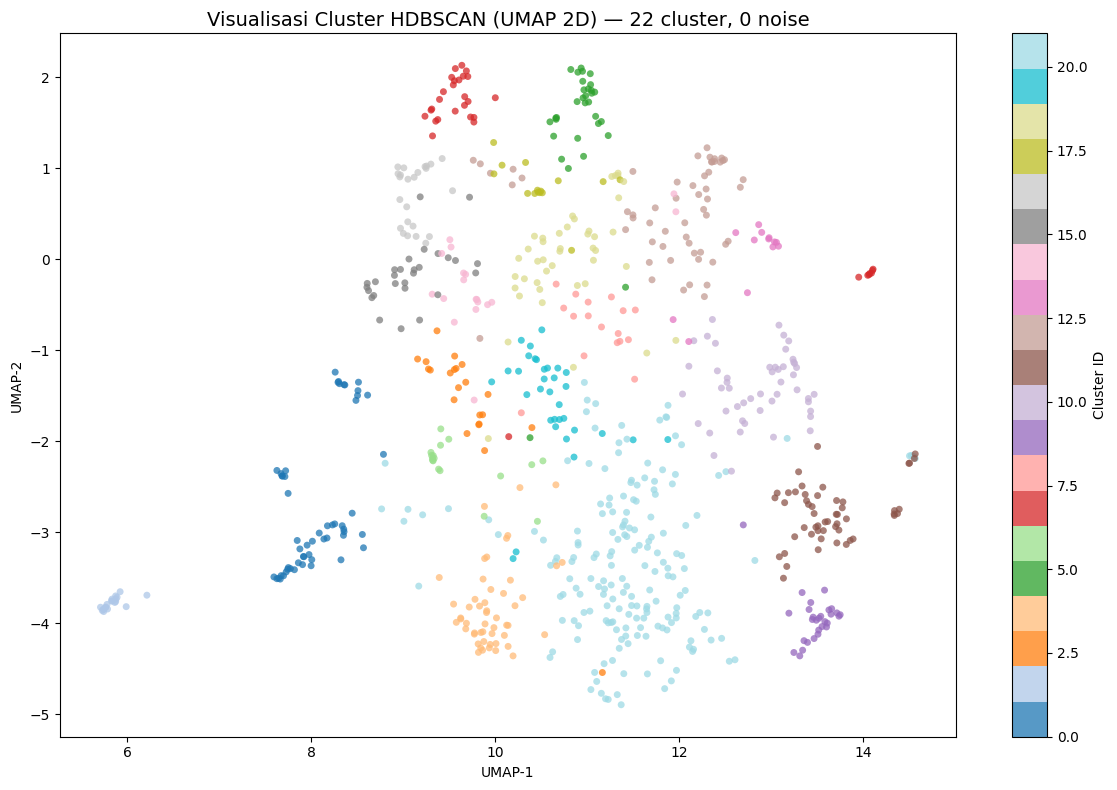

Visualisasi disimpan ke hasil_clustering/cluster_visualisasi.png


In [21]:
print("Membuat UMAP 2D untuk visualisasi...")
reducer_viz = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
)
emb_2d = reducer_viz.fit_transform(embeddings)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=cluster_labels, cmap="tab20",
    alpha=0.75, s=25, linewidths=0,
)
plt.colorbar(scatter, label="Cluster ID")
plt.title(f"Visualisasi Cluster HDBSCAN (UMAP 2D) — {n_clusters} cluster, 0 noise", fontsize=14)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cluster_visualisasi.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Visualisasi disimpan ke {OUTPUT_DIR}/cluster_visualisasi.png")

In [22]:
result_df = df[["id", "title", "clean_title", "category", "year", "author", "advisor", "url", "abstract", "cluster"]].copy()

all_csv_path = os.path.join(OUTPUT_DIR, "hasil_clustering_all.csv")
result_df.to_csv(all_csv_path, index=False)
print(f"Semua hasil: {all_csv_path}")

print("\nFile per cluster:")
for cid in sorted(result_df["cluster"].unique()):
    cluster_df = result_df[result_df["cluster"] == cid].copy()
    fname = "cluster_noise.csv" if cid == -1 else f"cluster_{cid}.csv"
    out_path = os.path.join(OUTPUT_DIR, fname)
    cluster_df.to_csv(out_path, index=False)
    label = "noise     " if cid == -1 else f"Cluster {cid:2d}"
    print(f"  {label} ({len(cluster_df):4d} judul): {out_path}")

Semua hasil: hasil_clustering\hasil_clustering_all.csv

File per cluster:
  Cluster  0 (  43 judul): hasil_clustering\cluster_0.csv
  Cluster  1 (  12 judul): hasil_clustering\cluster_1.csv
  Cluster  2 (  20 judul): hasil_clustering\cluster_2.csv
  Cluster  3 (  22 judul): hasil_clustering\cluster_3.csv
  Cluster  4 (  51 judul): hasil_clustering\cluster_4.csv
  Cluster  5 (  32 judul): hasil_clustering\cluster_5.csv
  Cluster  6 (  17 judul): hasil_clustering\cluster_6.csv
  Cluster  7 (  33 judul): hasil_clustering\cluster_7.csv
  Cluster  8 (  17 judul): hasil_clustering\cluster_8.csv
  Cluster  9 (  29 judul): hasil_clustering\cluster_9.csv
  Cluster 10 (  49 judul): hasil_clustering\cluster_10.csv
  Cluster 11 (  52 judul): hasil_clustering\cluster_11.csv
  Cluster 12 (  56 judul): hasil_clustering\cluster_12.csv
  Cluster 13 (  13 judul): hasil_clustering\cluster_13.csv
  Cluster 14 (  18 judul): hasil_clustering\cluster_14.csv
  Cluster 15 (  28 judul): hasil_clustering\cluster